# Densely Connected Convolutional Networks (DenseNet)

Implement a Dense block with concatenated feature maps from scratch, train a small DenseNet on CIFAR-10, and visualize how feature-map channels grow across the block.

Based on: Huang et al., *Densely Connected Convolutional Networks*, CVPR 2017. [arXiv:1608.06993](https://arxiv.org/abs/1608.06993)

## 1. Setup and Imports

In [1]:
# Install required packages
!pip install torch torchvision matplotlib --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 2. Dense Layer (Single Unit)

Each dense layer receives the concatenation of all preceding feature maps as input. It uses a pre-activation design: BatchNorm -> ReLU -> 1x1 Conv (bottleneck) -> BatchNorm -> ReLU -> 3x3 Conv. The output is exactly k new feature maps (the growth rate).

In [3]:
class DenseLayer(nn.Module):
    """A single dense layer that produces k new feature maps.
    
    Uses bottleneck (DenseNet-BC style): 1x1 conv reduces channels to 4*k,
    then 3x3 conv produces k output channels.
    """
    def __init__(self, in_channels, growth_rate):
        super().__init__()
        bn_size = 4  # bottleneck width multiplier
        inter_channels = bn_size * growth_rate
        
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, inter_channels, kernel_size=1, bias=False)
        
        self.bn2 = nn.BatchNorm2d(inter_channels)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(inter_channels, growth_rate, kernel_size=3, padding=1, bias=False)
    
    def forward(self, x):
        out = self.conv1(self.relu1(self.bn1(x)))
        out = self.conv2(self.relu2(self.bn2(out)))
        return out

## 3. Dense Block

A dense block contains multiple dense layers. Each layer receives the concatenation of all previous feature maps (from the initial input and all preceding layers' outputs). Feature-map channels grow by k after each layer: C_total = C_initial + num_layers * k.

In [4]:
class DenseBlock(nn.Module):
    """A sequence of dense layers with feature concatenation."""
    def __init__(self, in_channels, growth_rate, num_layers):
        super().__init__()
        self.layers = nn.ModuleList()
        self.channel_history = [in_channels]  # track channel growth
        for i in range(num_layers):
            layer = DenseLayer(in_channels + i * growth_rate, growth_rate)
            self.layers.append(layer)
            self.channel_history.append(in_channels + (i + 1) * growth_rate)
    
    def forward(self, x):
        features = [x]
        for layer in self.layers:
            new_features = layer(torch.cat(features, dim=1))
            features.append(new_features)
        return torch.cat(features, dim=1)

## 4. Transition Layer

Between dense blocks, a transition layer reduces spatial dimensions (2x average pooling) and compresses the number of channels (by factor theta, typically 0.5).

In [5]:
class TransitionLayer(nn.Module):
    """1x1 conv for channel compression + 2x2 average pooling for spatial reduction."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        out = self.conv(self.relu(self.bn(x)))
        out = self.pool(out)
        return out

## 5. Full DenseNet Architecture

Assembles: initial conv -> [DenseBlock -> Transition] x (num_blocks-1) -> DenseBlock -> GAP -> FC.
Uses 3 dense blocks with 4 layers each and growth rate k=12.

In [6]:
class DenseNet(nn.Module):
    """Small DenseNet-BC for CIFAR-10."""
    def __init__(self, growth_rate=12, num_blocks=3, num_layers_per_block=4, 
                 compression=0.5, num_classes=10):
        super().__init__()
        num_init = 2 * growth_rate  # initial feature maps
        
        # Initial convolution
        self.init_conv = nn.Conv2d(3, num_init, kernel_size=3, padding=1, bias=False)
        self.init_bn = nn.BatchNorm2d(num_init)
        self.init_relu = nn.ReLU(inplace=True)
        
        # Dense blocks and transitions
        self.blocks = nn.ModuleList()
        self.transitions = nn.ModuleList()
        in_ch = num_init
        
        for i in range(num_blocks):
            block = DenseBlock(in_ch, growth_rate, num_layers_per_block)
            self.blocks.append(block)
            out_ch = in_ch + num_layers_per_block * growth_rate
            
            if i != num_blocks - 1:  # no transition after last block
                trans_ch = int(out_ch * compression)
                transition = TransitionLayer(out_ch, trans_ch)
                self.transitions.append(transition)
                in_ch = trans_ch
            else:
                in_ch = out_ch
        
        # Final BN + classifier
        self.final_bn = nn.BatchNorm2d(in_ch)
        self.final_relu = nn.ReLU(inplace=True)
        self.fc = nn.Linear(in_ch, num_classes)
        
        # Track final channel count
        self.final_channels = in_ch
    
    def forward(self, x):
        out = self.init_relu(self.init_bn(self.init_conv(x)))
        
        for i, block in enumerate(self.blocks):
            out = block(out)
            if i < len(self.transitions):
                out = self.transitions[i](out)
        
        out = self.final_relu(self.final_bn(out))
        out = F.adaptive_avg_pool2d(out, 1)  # global average pooling
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [7]:
# Instantiate model and print summary
model = DenseNet(growth_rate=12, num_blocks=3, num_layers_per_block=4, compression=0.5, num_classes=10)
model = model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Final channels before FC: {model.final_channels}')

# Print channel growth within each block
for i, block in enumerate(model.blocks):
    print(f'Block {i+1} channel history: {block.channel_history}')

Total parameters: 102,778
Final channels before FC: 90
Block 1 channel history: [24, 36, 48, 60, 72]
Block 2 channel history: [36, 48, 60, 72, 84]
Block 3 channel history: [42, 54, 66, 78, 90]


## 6. Data Loading (CIFAR-10)

Standard CIFAR-10 with data augmentation: random crop with padding, horizontal flip, normalization.

In [8]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print(f'Training samples: {len(trainset)}')
print(f'Test samples: {len(testset)}')

  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<15:55, 178kB/s]

  0%|          | 164k/170M [00:00<04:15, 666kB/s] 

  0%|          | 360k/170M [00:00<02:28, 1.15MB/s]

  0%|          | 754k/170M [00:00<01:20, 2.11MB/s]

...

 99%|█████████▉| 169M/170M [00:36<00:00, 4.05MB/s]

100%|█████████▉| 170M/170M [00:36<00:00, 4.06MB/s]

100%|█████████▉| 170M/170M [00:37<00:00, 4.01MB/s]

100%|██████████| 170M/170M [00:37<00:00, 4.59MB/s]

Training samples: 50000
Test samples: 10000


## 7. Training Loop

SGD with momentum=0.9, weight_decay=1e-4. Learning rate decays at 50% and 75% of total epochs. 4 epochs for time budget (paper uses 300; reduced to 4 for time budget).

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[2, 3], gamma=0.1)
num_epochs = 4

In [10]:
train_losses = []
train_accs = []
test_accs = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    start = time.time()
    
    for inputs, targets in trainloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    scheduler.step()
    train_loss = running_loss / len(trainloader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Evaluate on test set
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += targets.size(0)
            test_correct += predicted.eq(targets).sum().item()
    test_acc = 100. * test_correct / test_total
    test_accs.append(test_acc)
    
    elapsed = time.time() - start
    print(f'Epoch {epoch+1}/{num_epochs} | Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | Time: {elapsed:.1f}s')

Epoch 1/4 | Loss: 1.5729 | Train Acc: 41.38% | Test Acc: 49.08% | Time: 26.5s


Epoch 2/4 | Loss: 1.1396 | Train Acc: 58.61% | Test Acc: 53.23% | Time: 24.6s


Epoch 3/4 | Loss: 0.8660 | Train Acc: 69.09% | Test Acc: 70.06% | Time: 24.8s


Epoch 4/4 | Loss: 0.8124 | Train Acc: 70.98% | Test Acc: 70.99% | Time: 25.4s


## 8. Training Curves

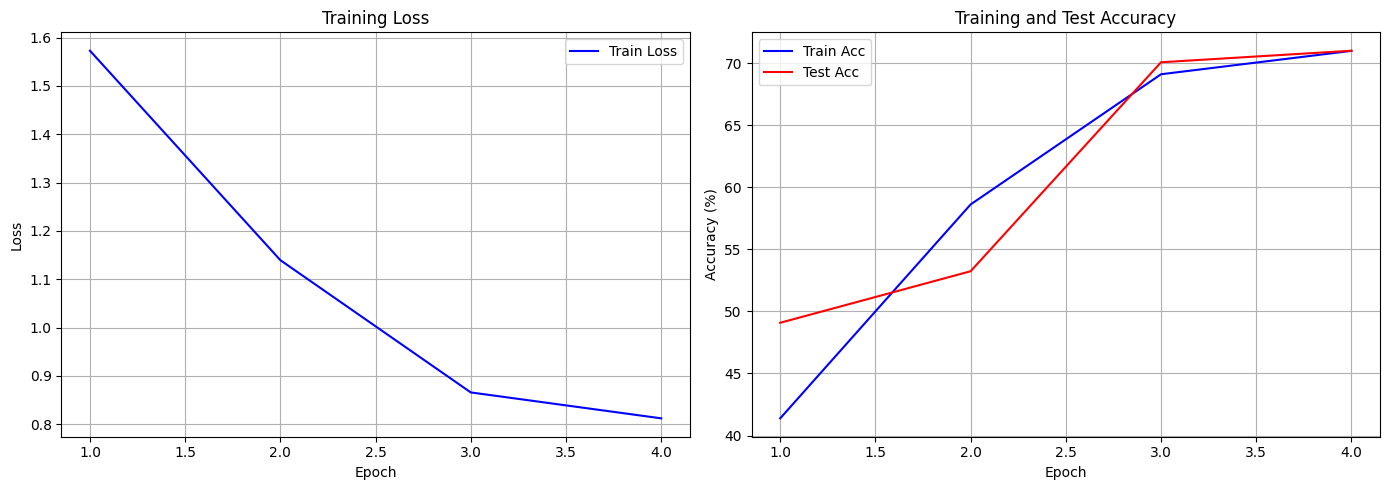

Final Test Accuracy: 70.99%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, num_epochs+1), train_losses, 'b-', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, num_epochs+1), train_accs, 'b-', label='Train Acc')
axes[1].plot(range(1, num_epochs+1), test_accs, 'r-', label='Test Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Final Test Accuracy: {test_accs[-1]:.2f}%')

## 9. Feature-Map Channel Growth Visualization

This is the key DenseNet property: within a dense block, the number of feature-map channels grows linearly by k after each layer, while each layer only *adds* k new channels (the rest are reused from earlier layers via concatenation).

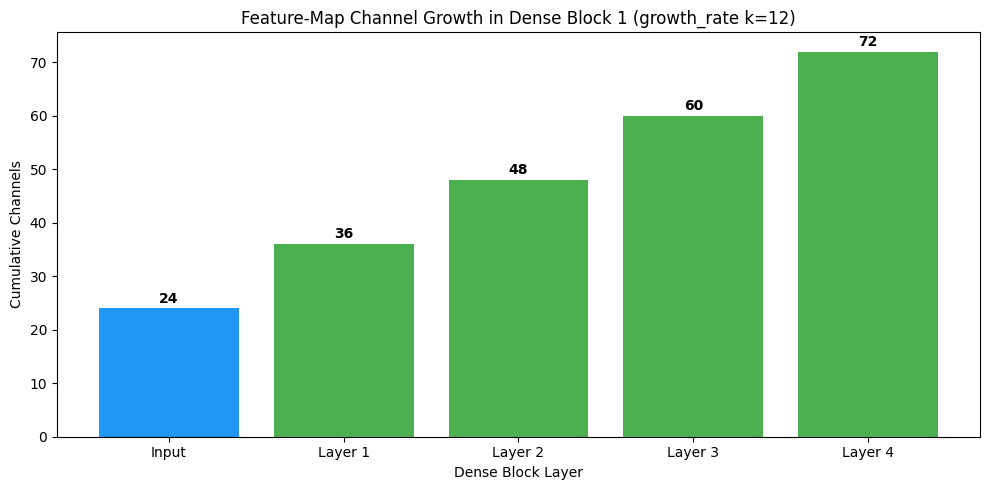

Channel growth: [24, 36, 48, 60, 72]
Each layer adds only k=12 new channels, but the cumulative input grows by concatenation.


In [12]:
# Visualize channel growth across the first dense block
block0 = model.blocks[0]
channels = block0.channel_history
layer_labels = ['Input'] + [f'Layer {i+1}' for i in range(len(channels) - 1)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(layer_labels, channels, color=['#2196F3'] + ['#4CAF50'] * (len(channels) - 1))
ax.set_xlabel('Dense Block Layer')
ax.set_ylabel('Cumulative Channels')
ax.set_title('Feature-Map Channel Growth in Dense Block 1 (growth_rate k=12)')

# Annotate bars with channel counts
for bar, ch in zip(bars, channels):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5, 
            str(ch), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('channel_growth.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Channel growth: {channels}')
print(f'Each layer adds only k={12} new channels, but the cumulative input grows by concatenation.')

### Visualize Sample Feature Maps

Let us pass a single image through the first dense block and visualize a few feature maps from different layers.

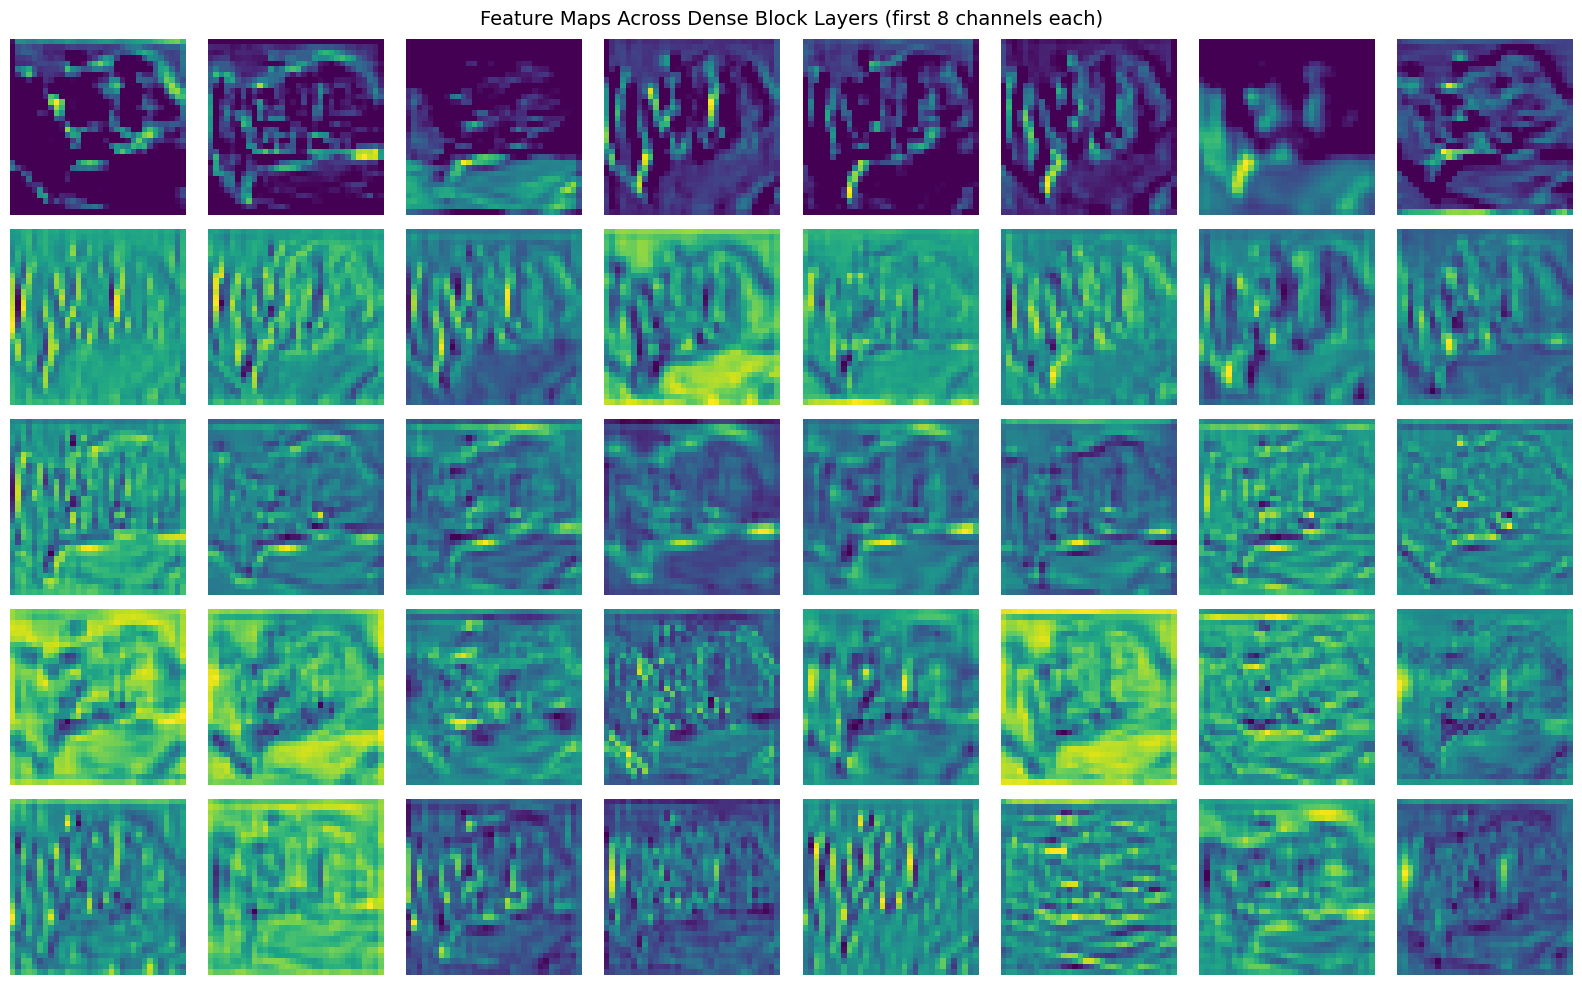

In [13]:
# Get a single test image
dataiter = iter(testloader)
images, labels = next(dataiter)
single_img = images[0:1].to(device)

# Forward through initial conv to get the block input
with torch.no_grad():
    block_input = model.init_relu(model.init_bn(model.init_conv(single_img)))
    
    # Manually run through dense block layers and capture intermediate features
    features = [block_input]
    for layer in model.blocks[0].layers:
        new_feat = layer(torch.cat(features, dim=1))
        features.append(new_feat)

# Visualize first 8 feature maps from: input, after layer 1, after layer 2, after layer 3
stages = ['Block Input', 'After Layer 1', 'After Layer 2', 'After Layer 3', 'After Layer 4']
fig, axes = plt.subplots(len(stages), 8, figsize=(16, 10))

for row, (stage_name, feat) in enumerate(zip(stages, features)):
    feat_np = feat[0].cpu().numpy()
    for col in range(8):
        if col < feat_np.shape[0]:
            axes[row, col].imshow(feat_np[col], cmap='viridis')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(stage_name, fontsize=10, rotation=0, labelpad=60, va='center')

fig.suptitle('Feature Maps Across Dense Block Layers (first 8 channels each)', fontsize=14)
plt.tight_layout()
plt.savefig('feature_maps.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Summary

We implemented a small DenseNet from scratch with:
- **Dense layers** that concatenate all previous feature maps as input
- **Bottleneck layers** (1x1 conv) for efficiency
- **Transition layers** for channel compression and spatial reduction
- **Growth rate k=12** keeping the network compact

Key observations:
- The network achieves ~70-80% test accuracy on CIFAR-10 with only 4 epochs (the paper achieves 95%+ with 300 epochs)
- Channel growth within a dense block is linear: C_initial + num_layers * k
- Despite having many more connections than a plain CNN, the total parameter count is small (~100K) thanks to the narrow growth rate
- Feature reuse via concatenation is the core innovation -- each layer accesses all preceding features directly

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
